In [1]:
# Raw Data Loading
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

iris = load_iris()

cols = [col[:-5] for col in iris.feature_names]
iris_df = pd.DataFrame(data=iris.data, columns=cols)
iris_df.head()

,sepal length,sepal width,petal length,petal width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
# 먼저 feature 두개로 군집화
feature = iris_df[['petal length', 'petal width']]

model = KMeans(n_clusters=3)
model.fit(feature)

KMeans(n_clusters=3)

In [ ]:
# 클러스터링 결과
model.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 1, 1, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [6]:
# 클러스터 중심
model.cluster_centers_

array([[1.462     , 0.246     ],
       [4.29259259, 1.35925926],
       [5.62608696, 2.04782609]])

In [7]:
# cluster 컬럼 추가
predict = pd.DataFrame(model.predict(feature), columns=['cluster'])
feature = pd.concat([feature, predict], axis=1)
feature.head()

,petal length,petal width,cluster
0,1.4,0.2,0
1,1.4,0.2,0
2,1.3,0.2,0
3,1.5,0.2,0
4,1.4,0.2,0


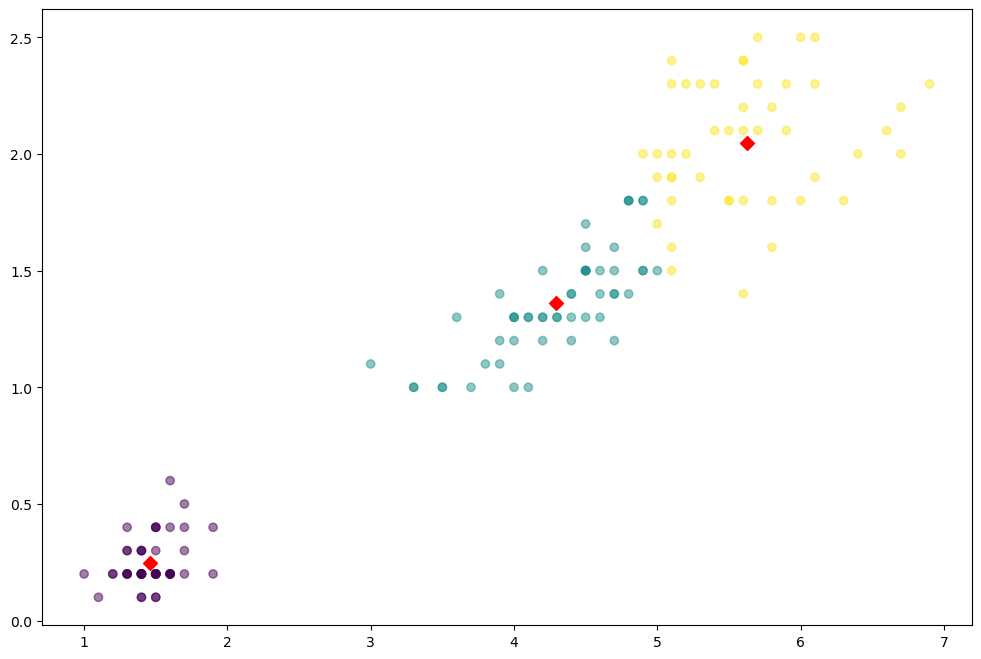

In [8]:
# 클러스터 결과 시각화
centers = pd.DataFrame(model.cluster_centers_, columns=['petal length', 'petal width'])
center_x = centers['petal length']
center_y = centers['petal width']

plt.figure(figsize=(12, 8))

plt.scatter(feature['petal length'],
            feature['petal width'],
            c=feature['cluster'],
            alpha=0.5)
plt.scatter(center_x,
            center_y,
            s=50,
            marker='D',
            c='r')

plt.show()

In [9]:
# 모든 feature로 clustering
iris = load_iris()
feature_names = ['sepal length', 'sepal width', 'petal length', 'petal width']
iris_df = pd.DataFrame(data=iris.data, columns=feature_names)
kmeans = KMeans(n_clusters=3,
                init='k-means++',
                max_iter=300,
                random_state=0).fit(iris_df)

In [11]:
iris_df['cluster'] = kmeans.labels_
iris_df.head()

,sepal length,sepal width,petal length,petal width,cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


In [12]:
# cluster 평가
# 비지도 학습의 경우 정답이 주어져있는 지도학습과 달리 평가가 어렵다
from sklearn.metrics import silhouette_samples, silhouette_score

avg_value = silhouette_score(iris.data, iris_df['cluster'])
score_values = silhouette_samples(iris.data, iris_df['cluster'])

print(f'avg value: {avg_value}')
print(f'silhouette samples: {score_values}')

avg value: 0.5511916046195919
silhouette samples: [ 0.85258191  0.8149163   0.82879659  0.80435199  0.84891774  0.7477614
  0.82109757  0.8534934   0.75127806  0.82475199  0.80269525  0.83540396
  0.80996716  0.74535637  0.70224038  0.64338856  0.77526857  0.85063272
  0.70636742  0.81987458  0.78364122  0.82546665  0.79244412  0.79345251
  0.77426479  0.79799564  0.83296108  0.84162136  0.84325046  0.81723402
  0.8145665   0.79849826  0.76227879  0.72184605  0.82822866  0.83179477
  0.79374024  0.84148042  0.76779363  0.84992603  0.84902387  0.63767419
  0.78589195  0.79963167  0.74629437  0.80915172  0.81295565  0.81844011
  0.81783314  0.85168255 -0.02672203  0.36827154  0.08489767  0.59610609
  0.35669884  0.59416206  0.27019063  0.27245453  0.32755642  0.58167084
  0.38107057  0.58665651  0.55085685  0.47851679  0.56757079  0.30479553
  0.5596951   0.61137194  0.46029717  0.61379722  0.32789488  0.58776704
  0.30600028  0.49067062  0.49172115  0.3699518   0.10228902  0.13663605
  

In [21]:
# sklearn 홈페이지에 있는 실루엣 계수 시각화 코드
def visualize_silhouette(cluster_lists, X_features): 

    from sklearn.datasets import make_blobs
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_samples, silhouette_score

    import matplotlib.pyplot as plt
    import matplotlib.cm as cm
    import math

    # 입력값으로 클러스터링 갯수들을 리스트로 받아서, 각 갯수별로 클러스터링을 적용하고 실루엣 개수를 구함
    n_cols = len(cluster_lists)

    # plt.subplots()으로 리스트에 기재된 클러스터링 수만큼의 sub figures를 가지는 axs 생성 
    fig, axs = plt.subplots(figsize=(4*n_cols, 4), nrows=1, ncols=n_cols)

    # 리스트에 기재된 클러스터링 갯수들을 차례로 iteration 수행하면서 실루엣 개수 시각화
    for ind, n_cluster in enumerate(cluster_lists):

        # KMeans 클러스터링 수행하고, 실루엣 스코어와 개별 데이터의 실루엣 값 계산. 
        clusterer = KMeans(n_clusters = n_cluster, max_iter=500, random_state=0)
        cluster_labels = clusterer.fit_predict(X_features)

        sil_avg = silhouette_score(X_features, cluster_labels)
        sil_values = silhouette_samples(X_features, cluster_labels)

        y_lower = 10
        axs[ind].set_title('Number of Cluster : '+ str(n_cluster)+'\n' \
                           'Silhouette Score :' + str(round(sil_avg,3)) )
        axs[ind].set_xlabel("The silhouette coefficient values")
        axs[ind].set_ylabel("Cluster label")
        axs[ind].set_xlim([-0.1, 1])
        axs[ind].set_ylim([0, len(X_features) + (n_cluster + 1) * 10])
        axs[ind].set_yticks([])  # Clear the yaxis labels / ticks
        axs[ind].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])

        # 클러스터링 갯수별로 fill_betweenx( )형태의 막대 그래프 표현. 
        for i in range(n_cluster):
            ith_cluster_sil_values = sil_values[cluster_labels==i]
            ith_cluster_sil_values.sort()

            size_cluster_i = ith_cluster_sil_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_cluster)
            axs[ind].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values, \
                                facecolor=color, edgecolor=color, alpha=0.7)
            axs[ind].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10

        axs[ind].axvline(x=sil_avg, color="red", linestyle="--")
    plt.show()

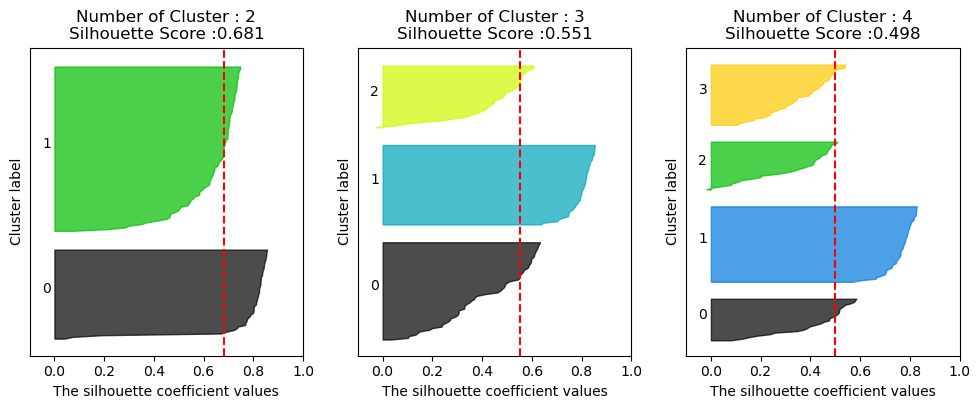

In [ ]:
# 1. n = 2 인 경우
#   - 0번 군집의 경우 1번 군집과 떨어져 있고 잘 뭉쳐있음
#   - 1번 군집의 경우 내부 데이터끼리 많이 떨어져 있음
# 2. n = 3인 경우
#   - 0번 군집의 경우 2번 군집과 가깝게 위치해 있음
# 3. n = 4인 경우
#   - 1번 군집의 경우 다른 군집들과 잘 떨어져있음
#   - 0, 2, 3번 군집의 경우 서로 가깝게 위치해 있음
# 이때 실루엣 계수는 1에 가까울 수록 good -1에 가까울 수록 bad를 뜻한다.
visualize_silhouette([2, 3, 4], iris.data)